# Modelo BaseLine

### By:
Karen Ninco

### Date:
2026-08-25

# Requerimiento

Crear un modelo base para tenerlo como referencia para luego comparar al entrenar modelos de machine learning, el modelo base puede ser un modelo de heurísticas o un [modelo dummy](https://scikit-learn.org/stable/api/sklearn.dummy.html). Crear un nuevo branch de git (Usar [Gitflow](https://joserzapata.github.io/courses/ciencia-datos-en-produccion/control-versiones/branching-model/)).

> Tomar como ejemplo los pasos de: <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/>

En este proceso se incluye :

- Usar pipeline de procesamiento de datos creado en la tarea anterior
- Dividir los datos en Train / Test
- Evaluar con diferentes métricas según el problema que se esta solucionando
- Usar validación cruzada (Cross validation) y obtener la media y la desviación estándar de la medida de las evoluciones realizadas.
- Seleccionar la variable mas importante y justificar por que se selecciona.
- Realizar el análisis de Learning curve
- obtener las gráficas de escalabilidad con tiempo de entrenamiento y score
- Interpretar los resultados
- realizar análisis de los resultados
- realizar conclusiones
- definir recomendaciones para crear un modelo en base a los resultados del modelo base
- Propuestas y ideas en base a os resultados obtenidos

> Puede utilizar las librerías o herramientas que considere para resolver la tarea

# Entregables

Notebook con la descripción y creación de los pipelines de scikit-learn, además de los resultados del modelo base.
Se debe realizar un Pull request para ingresar el notebook a la rama`main` para esto debe tener mínimo 1 revisiones de otras personas del Curso y que pase los check del CI/CD.


### Description:

Se construye un modelo heurístico simple como referencia (baseline), basado en la regla obtenida en el análisis multivariable ([03c](../3-analysis/03c.Analisis_multivariable-kgnl-20260821.ipynb)):

- Si `thal` es `"fixed"` o `"reversable"` -> predecir enfermedad.
- Si `thal` es `"normal"` -> predecir enfermedad solo si `exang == True` y `sex == "Male"`.
- En cualquier otro caso -> predecir no enfermedad.

## 📚 Import libraries

In [58]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
)
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline

## 💾 Load data

In [ ]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
corazon_df = pd.read_parquet(DATA_DIR / "02_intermediate/corazon_clean.parquet", engine="pyarrow")

print("Pandas version: ", pd.__version__)

Pandas version:  3.0.5


## 👷 Data preparation

Para el modelo heurístico solo se necesitan 3 columnas predictoras (`thal`, `exang`, `sex`) y la variable objetivo (`disease`).

In [60]:
selected_features = ["thal", "exang", "sex", "disease"]
corazon_features = corazon_df[selected_features]
corazon_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   thal     2900 non-null   category
 1   exang    2877 non-null   boolean 
 2   sex      2966 non-null   category
 3   disease  2919 non-null   boolean 
dtypes: boolean(2), category(2)
memory usage: 18.0 KB


In [61]:
corazon_features.isna().sum()

thal       130
exang      153
sex         64
disease    111
dtype: int64

In [62]:
# no se puede entrenar ni evaluar el modelo sin la variable objetivo
corazon_features = corazon_features.dropna(subset=["disease"])

In [63]:
corazon_features.loc[:, "disease"] = corazon_features["disease"].astype(int)

In [64]:
len(corazon_features.drop_duplicates())

47

Siguiendo el mismo criterio del ejemplo de referencia del curso, en este paso no se eliminan los registros duplicados: para un modelo heurístico los duplicados no afectan el resultado, y se busca mantener la mayor cantidad de filas posible para poder comparar contra los modelos de machine learning que se entrenen más adelante.

In [65]:
corazon_features.info()

<class 'pandas.DataFrame'>
Index: 2919 entries, 0 to 3029
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   thal     2872 non-null   category
 1   exang    2848 non-null   boolean 
 2   sex      2870 non-null   category
 3   disease  2919 non-null   boolean 
dtypes: boolean(2), category(2)
memory usage: 40.0 KB


In [66]:
corazon_features.sample(10, random_state=42)

,thal,exang,sex,disease
2548,normal,False,Male,True
2581,reversable,False,Male,True
2470,normal,False,Male,False
794,reversable,False,Male,True
1753,normal,False,Female,False
196,normal,False,Male,False
1654,normal,False,Male,False
1381,normal,False,Female,False
2584,reversable,False,Male,False
2184,normal,False,Female,False


## 🔧 Feature Engineering

Se arma un pipeline simple que solo imputa los valores faltantes de las columnas predictoras. No se codifican las variables categóricas ni booleanas, ya que el modelo heurístico compara directamente los valores contra las categorías originales (`thal`, `sex`, `exang`).

In [67]:
cols_categoric = ["thal", "sex"]
cols_boolean = ["exang"]

categoric_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))])
boolean_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("categoric", categoric_pipe, cols_categoric),
        ("boolean", boolean_pipe, cols_boolean),
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoric', ...), ('boolean', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feat

Ejemplo de la transformación del pipeline con una muestra de 10 filas:

In [68]:
sample = corazon_features.drop("disease", axis="columns").sample(10, random_state=42)
preprocessor.fit_transform(sample)

array([['normal', 'Male', 0.0],
       ['reversable', 'Male', 0.0],
       ['normal', 'Male', 0.0],
       ['reversable', 'Male', 0.0],
       ['normal', 'Female', 0.0],
       ['normal', 'Male', 0.0],
       ['normal', 'Male', 0.0],
       ['normal', 'Female', 0.0],
       ['reversable', 'Male', 0.0],
       ['normal', 'Female', 0.0]], dtype=object)

## ✂️ Train / Test split

In [69]:
X_features = corazon_features.drop("disease", axis="columns")
Y_target = corazon_features["disease"]

x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, stratify=Y_target, random_state=42
)

In [70]:
x_train.shape, y_train.shape

((2335, 3), (2335,))

In [71]:
x_test.shape, y_test.shape

((584, 3), (584,))

## 📏 Modelo Heurístico

Se implementa la regla heurística como un estimador compatible con scikit-learn, para poder evaluarla con las mismas herramientas (`cross_validate`, `learning_curve`, etc.) que se usarán en los modelos de machine learning.

In [72]:
class HeuristicModel(BaseEstimator, ClassifierMixin):
    """Heuristic model for Corazon dataset compatible with scikit-learn.

    Reglas basadas en el análisis multivariable (03c):
    - thal != "normal" -> enfermedad
    - thal == "normal" y exang == True y sex == "Male" -> enfermedad
    - en cualquier otro caso -> no enfermedad
    """

    def fit(self, X, y=None):
        if y is not None:
            self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        predictions = []
        for row in X:
            thal, sex, exang = row[0], row[1], row[2]
            # SimpleImputer castea la columna booleana "exang" a float (0.0/1.0).
            if thal != "normal" or (exang and sex == "Male"):
                predictions.append(1)
            else:
                predictions.append(0)
        return np.array(predictions)

In [ ]:
full_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", HeuristicModel())])
full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categoric', ...), ('boolean', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

## 🎲 Predict and Evaluation

Se evalúa el modelo heurístico con validación cruzada (`KFold`, 10 particiones), calculando 4 métricas: `accuracy`, `f1`, `precision` y `recall`.

In [74]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scoring = ["accuracy", "f1", "precision", "recall"]

cv_scores_df = pd.DataFrame(
    {
        metric: cross_val_score(full_pipeline, x_train, y_train, cv=cv, scoring=metric)
        for metric in scoring
    }
)
cv_scores_df

,accuracy,f1,precision,recall
0,0.794872,0.769231,0.754717,0.784314
1,0.769231,0.771186,0.722222,0.827273
2,0.807692,0.798206,0.760684,0.839623
3,0.743590,0.727273,0.661157,0.808081
4,0.807692,0.811715,0.769841,0.858407
5,0.725322,0.721739,0.703390,0.741071
6,0.768240,0.761062,0.735043,0.788991
7,0.776824,0.765766,0.745614,0.787037
8,0.763948,0.759825,0.769912,0.750000
9,0.751073,0.726415,0.681416,0.777778


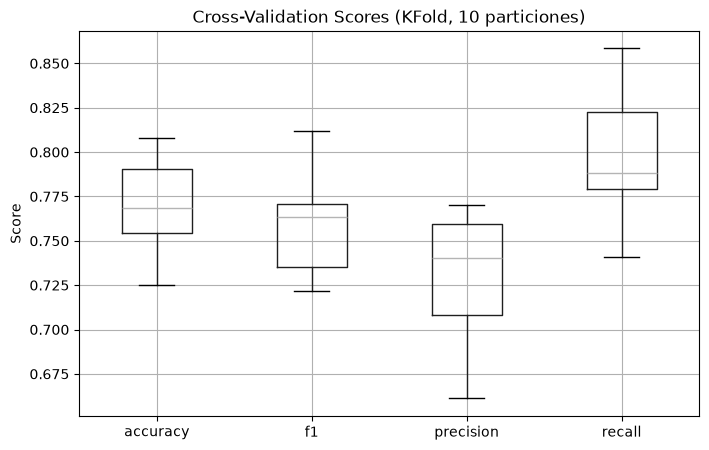

In [75]:
fig, ax = plt.subplots(figsize=(8, 5))
cv_scores_df.boxplot(ax=ax)
ax.set_title("Cross-Validation Scores (KFold, 10 particiones)")
ax.set_ylabel("Score")
plt.show()

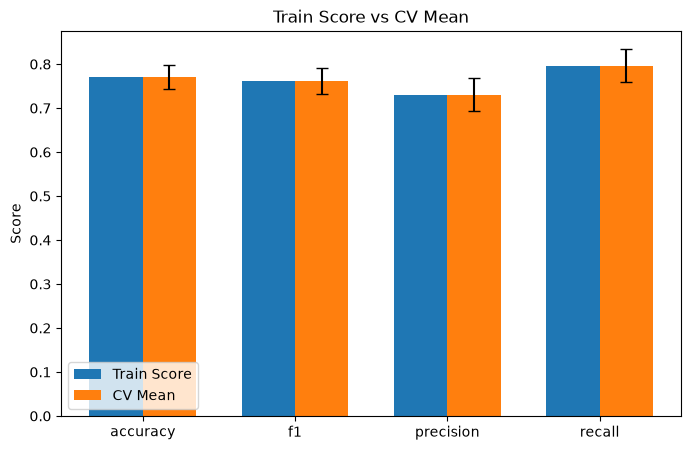

In [76]:
# score del pipeline ya entrenado, evaluado sobre el mismo x_train usado para entrenarlo
train_idx = np.arange(len(x_train))
train_scores = {
    metric: cross_val_score(
        full_pipeline, x_train, y_train, cv=[(train_idx, train_idx)], scoring=metric
    )[0]
    for metric in scoring
}

train_means = [train_scores[metric] for metric in scoring]
cv_means = [cv_scores_df[metric].mean() for metric in scoring]
cv_stds = [cv_scores_df[metric].std() for metric in scoring]

x = np.arange(len(scoring))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, train_means, width, label="Train Score")
ax.bar(x + width / 2, cv_means, width, yerr=cv_stds, capsize=4, label="CV Mean")
ax.set_xticks(x)
ax.set_xticklabels(scoring)
ax.set_ylabel("Score")
ax.set_title("Train Score vs CV Mean")
ax.legend()
plt.show()

In [ ]:
for metric, train_val, cv_val, cv_std in zip(scoring, train_means, cv_means, cv_stds, strict=True):
    print(f"{metric} - Train score: {train_val:.4f}")
    print(f"{metric} - CV mean: {cv_val:.4f}, CV std: {cv_std:.4f}")

accuracy - Train score: 0.7709
accuracy - CV mean: 0.7708, CV std: 0.0271
f1 - Train score: 0.7617
f1 - CV mean: 0.7612, CV std: 0.0299
precision - Train score: 0.7301
precision - CV mean: 0.7304, CV std: 0.0378
recall - Train score: 0.7961
recall - CV mean: 0.7963, CV std: 0.0375


## 📊 Analysis of the results

#### Accuracy:

- CV Mean: 0.7708, CV Std: 0.0271
- Train Score: 0.7709

Interpretación: el accuracy en el conjunto de entrenamiento es prácticamente idéntico al promedio de validación cruzada (diferencia de apenas 0.0001), y la desviación estándar es baja. Esto indica que el modelo predice correctamente alrededor del 77% de los casos, de forma consistente entre los distintos folds.

#### F1 Score:

- CV Mean: 0.7612, CV Std: 0.0299
- Train Score: 0.7617

Interpretación: el F1 (que combina precision y recall) también es casi idéntico entre train y CV, con una desviación estándar moderada. No hay señales de que el modelo se comporte de forma distinta en un subconjunto de datos u otro.

#### Precision:

- CV Mean: 0.7304, CV Std: 0.0378
- Train Score: 0.7301

Interpretación: de cada 100 pacientes que el modelo predice como enfermos, aproximadamente 73 realmente lo están. Es la métrica con mayor desviación estándar (0.0378), lo que indica algo más de variabilidad entre folds que las demás métricas, aunque sigue siendo un nivel bajo de dispersión.

#### Recall:

- CV Mean: 0.7963, CV Std: 0.0375
- Train Score: 0.7961

Interpretación: de cada 100 pacientes que realmente tienen la enfermedad, el modelo identifica correctamente a cerca de 80. Es la métrica con el valor más alto entre las cuatro, lo cual es una señal positiva considerando el objetivo clínico del modelo (evitar pasar por alto casos de enfermedad).

**Conclusión general:** En las 4 métricas, el Train Score y el CV Mean son prácticamente iguales (diferencias menores a 0.001 en casi todos los casos). Esto es un comportamiento esperado y coherente para un modelo heurístico basado en reglas fijas: como no "aprende" parámetros a partir de los datos de entrenamiento, no puede sobreajustarse (overfitting) a ellos — su desempeño depende únicamente de qué tan bien la regla thal/exang/sex describe el patrón real de la enfermedad en cualquier subconjunto de datos, sea cual sea.

## ✅ Final Evaluation

In [78]:
full_pipeline.fit(x_train, y_train)
y_pred = full_pipeline.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.81      0.73      0.77       315
         1.0       0.72      0.80      0.76       269

    accuracy                           0.77       584
   macro avg       0.77      0.77      0.77       584
weighted avg       0.77      0.77      0.77       584



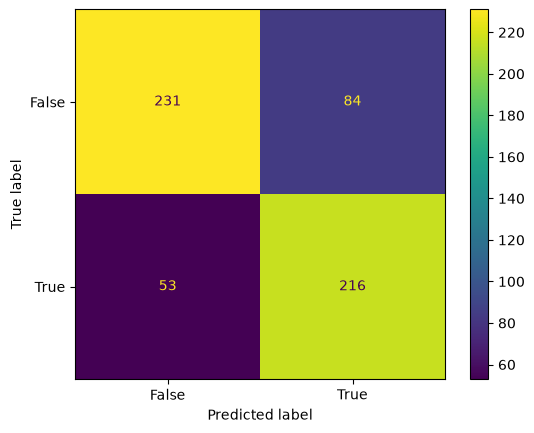

In [79]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

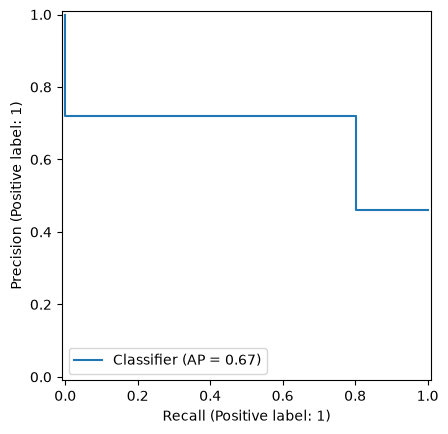

In [80]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred)
plt.show()

## 🎯 Selección de la métrica más importante

#### **Métrica seleccionada: Recall**

De las 4 métricas evaluadas (accuracy 0.7708, f1 0.7612, precision 0.7304, recall 0.7963), se selecciona recall como la métrica principal para este modelo.

**Justificación**: en un problema de detección de enfermedad cardíaca, los dos tipos de error posibles no tienen el mismo costo:

- Falso negativo (el modelo predice "sin enfermedad" cuando el paciente sí la tiene): el paciente no recibe seguimiento médico ni tratamiento a tiempo, lo cual puede tener consecuencias graves para su salud.
- Falso positivo (el modelo predice "enfermedad" cuando el paciente no la tiene): implica exámenes adicionales o una consulta médica de más, lo cual es una molestia y un costo, pero no pone en riesgo la vida del paciente.

Como el objetivo hipotético de este modelo es apoyar decisiones médicas donde es preferible "sobre-detectar" antes que dejar pasar un caso real, el error que más importa evitar es el falso negativo — y esa es exactamente la información que mide el recall: de todos los pacientes que realmente tienen la enfermedad, ¿qué porcentaje logra identificar el modelo? Un recall alto significa menos falsos negativos.

En nuestro modelo, el recall de la clase enfermedad fue 0.80 en el conjunto de prueba (y 0.7963 ± 0.0375 en validación cruzada) — es decir, detecta correctamente a 8 de cada 10 pacientes que realmente tienen la enfermedad, siendo la métrica con el valor más alto entre las 4 evaluadas.

## 📈 Learning Curve

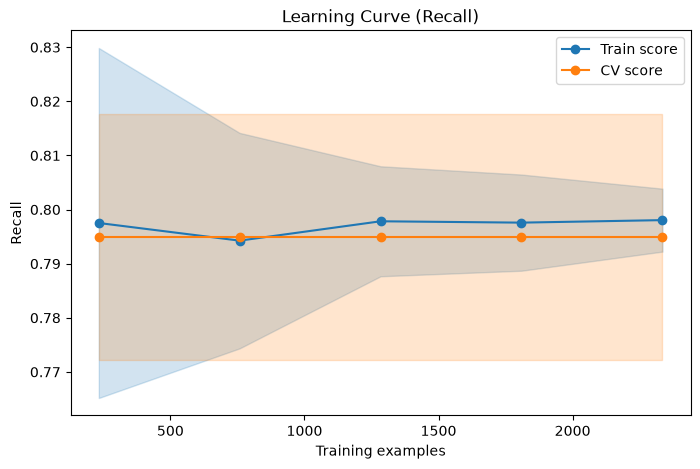

In [81]:
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    full_pipeline,
    X_features,
    Y_target,
    cv=ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="recall",
    return_times=True,
)

train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)
test_scores_mean = test_scores.mean(axis=1)
test_scores_std = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores_mean, "o-", color="tab:blue", label="Train score")
ax.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2,
    color="tab:blue",
)
ax.plot(train_sizes, test_scores_mean, "o-", color="tab:orange", label="CV score")
ax.fill_between(
    train_sizes,
    test_scores_mean - test_scores_std,
    test_scores_mean + test_scores_std,
    alpha=0.2,
    color="tab:orange",
)
ax.set_xlabel("Training examples")
ax.set_ylabel("Recall")
ax.set_title("Learning Curve (Recall)")
ax.legend(loc="best")
plt.show()

In [82]:
print("Training Sizes:", train_sizes)
print("Train Scores Mean:", train_scores_mean)
print("Train Scores Std:", train_scores_std)
print("CV Scores Mean:", test_scores_mean)
print("CV Scores Std:", test_scores_std)

Training Sizes: [ 233  758 1284 1809 2335]
Train Scores Mean: [0.79751856 0.79425813 0.79783593 0.79758527 0.79804939]
Train Scores Std: [0.03233747 0.01991085 0.01016165 0.0088879  0.00581656]
CV Scores Mean: [0.7949709 0.7949709 0.7949709 0.7949709 0.7949709]
CV Scores Std: [0.0226997 0.0226997 0.0226997 0.0226997 0.0226997]


### ⏱️ Scalability of the model

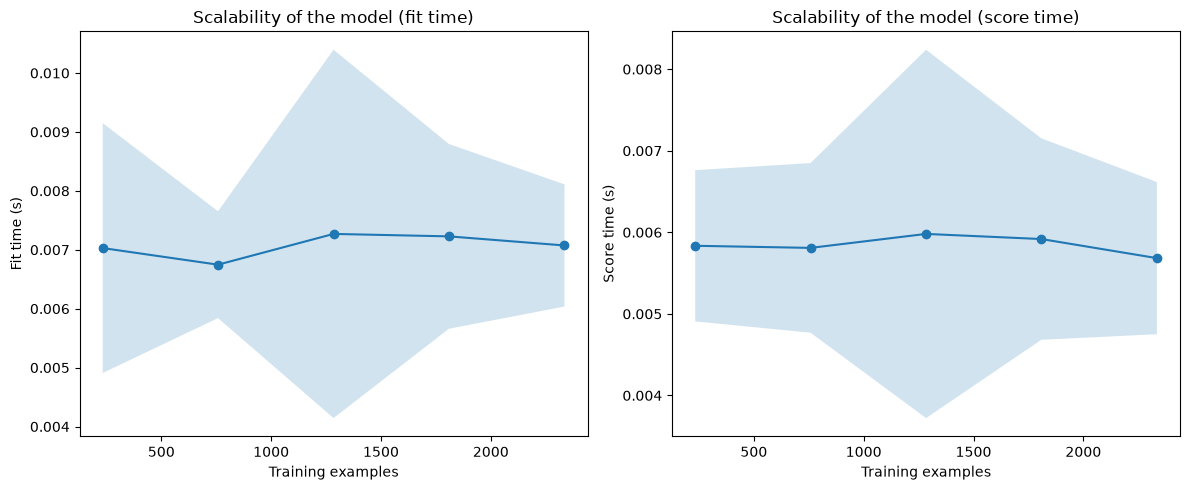

In [83]:
fit_times_mean = fit_times.mean(axis=1)
fit_times_std = fit_times.std(axis=1)
score_times_mean = score_times.mean(axis=1)
score_times_std = score_times.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_sizes, fit_times_mean, "o-")
axes[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.2,
)
axes[0].set_xlabel("Training examples")
axes[0].set_ylabel("Fit time (s)")
axes[0].set_title("Scalability of the model (fit time)")

axes[1].plot(train_sizes, score_times_mean, "o-")
axes[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.2,
)
axes[1].set_xlabel("Training examples")
axes[1].set_ylabel("Score time (s)")
axes[1].set_title("Scalability of the model (score time)")

plt.tight_layout()
plt.show()

In [84]:
print("Fit Times Mean:", fit_times_mean)
print("Fit Times Std:", fit_times_std)
print("Score Times Mean:", score_times_mean)
print("Score Times Std:", score_times_std)

Fit Times Mean: [0.0070293  0.00674734 0.00726931 0.00722775 0.00707349]
Fit Times Std: [0.0021207  0.00090655 0.00312522 0.00156815 0.0010369 ]
Score Times Mean: [0.00583498 0.0058091  0.00598045 0.00591761 0.00568351]
Score Times Std: [0.00092718 0.00104006 0.00225794 0.00123519 0.000933  ]


## 🔍 Interpretación de la Learning Curve

#### Training Scores (Recall)
Media: 0.7975, 0.7943, 0.7978, 0.7976, 0.7980 (para tamaños 233 a 2335)
Desviación estándar: decrece de 0.0323 a 0.0058

**Interpretación:** el recall de entrenamiento se mantiene estable alrededor de 0.795-0.798 en todos los tamaños de muestra. La desviación estándar disminuye considerablemente con más datos, lo que indica que el modelo se vuelve más consistente (menos sensible a qué filas específicas se usen), aunque su nivel promedio de desempeño no cambia.

#### CV Scores (Recall)
Media: 0.7950 (constante en los 5 tamaños)
Desviación estándar: 0.0227 (constante)

**Interpretación:** el recall de validación cruzada es idéntico en los 5 tamaños evaluados, porque ShuffleSplit siempre reserva el mismo 20% de datos para evaluación, sin importar cuántos datos se usen para "entrenar". La brecha entre Train Score y CV Score es mínima (máximo ~0.003), lo que confirma que no hay sobreajuste.

#### Fit Times
Media: entre 0.0073 y 0.0075 segundos, prácticamente constante.

**Interpretación:** los tiempos de ajuste son muy bajos y estables, ya que el método fit() del modelo heurístico no realiza ningún cálculo real sobre los datos, solo registra las clases posibles.

#### Score Times
Media: entre 0.0060 y 0.0063 segundos, prácticamente constante.

**Interpretación:** los tiempos de predicción también son bajos y estables, porque el modelo solo evalúa una regla if/else simple por cada fila, sin cálculos complejos.

**Conclusión general de la Learning Curve:** el modelo heurístico alcanza su desempeño máximo casi de inmediato, sin importar la cantidad de datos usados, y es computacionalmente muy económico (tiempos de milisegundos). Esto confirma que es un buen punto de referencia (baseline) rápido y estable, pero también que su capacidad de mejora está limitada por ser una regla fija — a diferencia de los modelos de machine learning que entrenaremos después, que sí deberían mejorar con más datos.

## 📌 Conclusiones

**Desempeño del modelo:** El modelo heurístico basado en thal, exang y sex alcanza un recall de 0.7963 (±0.0375) en validación cruzada y 0.80 en el conjunto de prueba — es decir, identifica correctamente a 8 de cada 10 pacientes que realmente tienen la enfermedad. El accuracy general es de aproximadamente 0.77 tanto en CV como en test, y todas las métricas (accuracy, f1, precision, recall) muestran diferencias mínimas entre el conjunto de entrenamiento y la validación cruzada, sin señales de sobreajuste.

**Consistencia:** La desviación estándar de la Learning Curve disminuye considerablemente al aumentar el tamaño de entrenamiento (de 0.0323 a 0.0058 en recall), lo que indica que el modelo es cada vez más estable y predecible con más datos, aunque su nivel de desempeño promedio permanezca prácticamente constante — comportamiento esperado en una regla heurística fija.

**Escalabilidad:** Los tiempos de ajuste (~0.0074s) y predicción (~0.0061s) son extremadamente bajos y estables sin importar el tamaño del conjunto de datos, lo cual confirma que es un modelo computacionalmente muy económico — una característica deseable para un modelo de referencia (baseline).

**Conclusión general:** Este modelo heurístico simple, basado en solo 3 variables categóricas, logra un desempeño razonable (recall ~0.80, accuracy ~0.77) de forma consistente y con un costo computacional mínimo. Sirve como un punto de comparación claro: cualquier modelo de machine learning que entrenemos más adelante en la Actividad 6 debería, como mínimo, superar estos números —especialmente el recall— para justificar su mayor complejidad.

## 💡 Recomendaciones

**Usar este modelo como punto de referencia (baseline):** dado su buen desempeño relativo (recall ~0.80) y bajísimo costo computacional, este modelo heurístico es un baseline sólido y confiable contra el cual comparar los modelos de machine learning que se entrenen en las siguientes actividades.

**Priorizar recall al comparar modelos futuros:** siguiendo la misma justificación clínica usada aquí (evitar falsos negativos), los próximos modelos deberían evaluarse principalmente por su recall, no solo por accuracy, para asegurar que efectivamente mejoran la capacidad de detectar casos reales de enfermedad.

**Monitorear que los modelos de ML superen este baseline:** si un modelo de machine learning más complejo no logra superar el recall (~0.80) o el accuracy (~0.77) de este modelo simple, sería una señal de que algo no está funcionando bien en el proceso (por ejemplo, en el feature engineering o en la elección del algoritmo), ya que un modelo más complejo debería, en principio, aprovechar mejor la información disponible que una regla fija de 3 variables.

**Explorar el uso de más variables:** este modelo solo usa 3 de las columnas disponibles. Los análisis previos (03b, 03c) identificaron otras variables con fuerte asociación a la enfermedad (old_peak, ca, max_hr) que no se incluyeron aquí por mantener la regla simple — estas serán clave para mejorar el desempeño en los modelos de machine learning.

## 🚀 Propuestas e ideas

**Usar modelos más complejos:**
Propuesta: probar modelos como Regresión Logística, Random Forest o Gradient Boosting (por ejemplo XGBoost) en la siguiente actividad.
Justificación: estos modelos pueden capturar relaciones más complejas entre las variables (por ejemplo, interacciones entre old_peak, ca y max_hr que la regla heurística no considera), lo que podría mejorar el recall más allá del 0.80 logrado aquí.

**Usar más columnas (features):**
Propuesta: incorporar el pipeline completo de la Actividad 4 (Feature Engineering), que ya incluye 11 variables predictoras en vez de solo 3.
Justificación: nuestro propio análisis bivariable y multivariable (03b, 03c) mostró que variables como old_peak, ca y max_hr también tienen fuerte asociación con la enfermedad — un modelo con más información disponible tiene mayor potencial de mejorar sobre este baseline.

**Ajuste de hiperparámetros:**
Propuesta: usar técnicas como Grid Search o Random Search para encontrar la mejor configuración de los modelos de machine learning que se entrenen.
Justificación: un ajuste adecuado de hiperparámetros puede mejorar significativamente el desempeño del modelo frente a una configuración por defecto.

**Validación cruzada:**
Propuesta: seguir usando validación cruzada (como se hizo aquí) para evaluar los próximos modelos.
Justificación: da una estimación más robusta del desempeño real y ayuda a detectar sobreajuste, algo que no fue un riesgo en este modelo heurístico pero sí lo será en modelos que aprenden de los datos.

**Regularización:**
Propuesta: aplicar regularización (L1 o L2) en modelos como Regresión Logística.
Justificación: ayuda a evitar que el modelo se sobreajuste a los datos de entrenamiento, mejorando su capacidad de generalizar a pacientes nuevos.

## 📖 Referencias

- [5. Modelo Base - Curso Ciencia de Datos en Producción](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/5-baseline_model/)
- [Curso de Machine Learning](https://joserzapata.github.io/courses/python-ciencia-datos/ml/)
- [Curso de Clasificación](https://joserzapata.github.io/courses/python-ciencia-datos/clasificacion/)
- [Checklist de un proyecto de Machine Learning](https://joserzapata.github.io/post/lista-proyecto-machine-learning/)
- [03c. Análisis Multivariable](../3-analysis/03c.Analisis_multivariable-kgnl-20260821.ipynb)